# Grupo 16 - Proyecto Data Science
## Semáforo Financiero: clasificación de empresas según sus ratios contables-financieros
**Objetivo:** construir un semáforo (Aceptable / Medio / Regular) que clasifique a cada empresa comparando sus ratios financiero-contables contra la media de su propio sector, año a año.

**Fuente de datos:** "200+ Financial Indicators of US stocks (2014-2018)", Kaggle, usuario Nicolas Carbone.
URL: https://www.kaggle.com/datasets/cnic92/200-financial-indicators-of-us-stocks-20142018

**Importante:** el semáforo lo construimos nosotros a partir de los mismos ratios que después vamos a usar para describir a cada empresa. No es lo mismo que la columna `Class` que ya viene en el dataset (esa indica si el precio de la acción subió o bajó al año siguiente, y no la vamos a usar como target).

## 0. Preparación del entorno

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    MinMaxScaler,
    StandardScaler,
    Normalizer,
    PowerTransformer,
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

print("Versión de pandas:", pd.__version__)



Versión de pandas: 3.0.5


### Carga de datos y Diagnóstico inicial

## 1. Carga y unificación de los 5 años

Se subió los 5 archivos (`2014_Financial_Data.csv` - `2018_Financial_Data.csv`) y se guardaron con nombres.
Cuántas filas y columnas hay y de qué tipo es cada variable. Lo hacemos solo con una de las 5 tablas para conocer su estructura.

In [2]:
#define los data frames y lee los .csv

df= pd.read_csv("2014_Financial_Data.csv")
df1= pd.read_csv("2015_Financial_Data.csv")
df2= pd.read_csv("2016_Financial_Data.csv")
df3= pd.read_csv("2017_Financial_Data.csv")
df4= pd.read_csv("2018_Financial_Data.csv")

#imprime por consola las primeras 5 filas del DataFrame
print(df.head())

# Imprime info completa del DF
print(df.info())

# Obtengo el nombre de las columnas
df.columns




  Unnamed: 0       Revenue  Revenue Growth  Cost of Revenue  Gross Profit  \
0         PG  7.440100e+10         -0.0713     3.903000e+10  3.537100e+10   
1       VIPS  3.734148e+09          1.1737     2.805625e+09  9.285226e+08   
2         KR  9.837500e+10          0.0182     7.813800e+10  2.023700e+10   
3        RAD  2.552641e+10          0.0053     1.820268e+10  7.323734e+09   
4        GIS  1.790960e+10          0.0076     1.153980e+10  6.369800e+09   

   R&D Expenses  SG&A Expense  Operating Expenses  Operating Income  \
0  0.000000e+00  2.146100e+10        2.146100e+10      1.391000e+10   
1  1.083303e+08  3.441414e+08        7.939267e+08      1.345959e+08   
2  0.000000e+00  1.519600e+10        1.751200e+10      2.725000e+09   
3  0.000000e+00  6.561162e+09        6.586482e+09      7.372520e+08   
4  0.000000e+00  3.474300e+09        3.412400e+09      2.957400e+09   

   Interest Expense  Earnings before Tax  Income Tax Expense  \
0      7.090000e+08         1.449400e+10      

Index(['Unnamed: 0', 'Revenue', 'Revenue Growth', 'Cost of Revenue',
       'Gross Profit', 'R&D Expenses', 'SG&A Expense', 'Operating Expenses',
       'Operating Income', 'Interest Expense',
       ...
       'Receivables growth', 'Inventory Growth', 'Asset Growth',
       'Book Value per Share Growth', 'Debt Growth', 'R&D Expense Growth',
       'SG&A Expenses Growth', 'Sector', '2015 PRICE VAR [%]', 'Class'],
      dtype='str', length=225)

## Unificación de los 5 años

Se crea una sola tabla con los 5 .cvs creando una columna "anio" y nombrando la columna del nombre de las empresas como "Tiker" que se detecto como Unnamed (sin nombre).


In [3]:
anios = [2014, 2015, 2016, 2017, 2018]
tablas = []

for anio in anios:
    tabla = pd.read_csv(f"{anio}_Financial_Data.csv")
    columna_precio = [c for c in tabla.columns if "PRICE VAR" in c][0]
    tabla = tabla.rename(columns={
        "Unnamed: 0": "Ticker",
        columna_precio: "Price Var Next Year",
    }).copy()
    tabla["Year"] = anio
    tablas.append(tabla)

df_completo = pd.concat(tablas, ignore_index=True)
print("Filas:", df_completo.shape[0], "| Columnas:", df_completo.shape[1])
df_completo.head()

Filas: 22077 | Columnas: 226


,Ticker,Revenue,Revenue Growth,Cost of Revenue,Gross Profit,R&D Expenses,SG&A Expense,Operating Expenses,Operating Income,Interest Expense,Earnings before Tax,Income Tax Expense,Net Income - Non-Controlling int,Net Income - Discontinued ops,Net Income,Preferred Dividends,Net Income Com,EPS,EPS Diluted,Weighted Average Shs Out,Weighted Average Shs Out (Dil),Dividend per Share,Gross Margin,EBITDA Margin,EBIT Margin,...,5Y Revenue Growth (per Share),3Y Revenue Growth (per Share),10Y Operating CF Growth (per Share),5Y Operating CF Growth (per Share),3Y Operating CF Growth (per Share),10Y Net Income Growth (per Share),5Y Net Income Growth (per Share),3Y Net Income Growth (per Share),10Y Shareholders Equity Growth (per Share),5Y Shareholders Equity Growth (per Share),3Y Shareholders Equity Growth (per Share),10Y Dividend per Share Growth (per Share),5Y Dividend per Share Growth (per Share),3Y Dividend per Share Growth (per Share),Receivables growth,Inventory Growth,Asset Growth,Book Value per Share Growth,Debt Growth,R&D Expense Growth,SG&A Expenses Growth,Sector,Price Var Next Year,Class,Year
0,PG,7.440100e+10,-0.0713,3.903000e+10,3.537100e+10,0.000000e+00,2.146100e+10,2.146100e+10,1.391000e+10,7.090000e+08,1.449400e+10,2.851000e+09,1.420000e+08,-1.127000e+09,1.164300e+10,0.0,1.164300e+10,4.1900,4.010,2.705960e+09,2.705960e+09,2.448,0.4754,0.2470,0.2043,...,0.0088,-0.0182,0.0355,0.0015,0.0260,0.0603,-0.0137,0.0060,0.1442,0.0353,0.0201,0.1013,0.0834,0.0751,-0.0187,-0.0217,0.0359,0.0316,0.1228,0.0000,-0.1746,Consumer Defensive,-9.323276,0,2014
1,VIPS,3.734148e+09,1.1737,2.805625e+09,9.285226e+08,1.083303e+08,3.441414e+08,7.939267e+08,1.345959e+08,1.214869e+07,1.753823e+08,3.955957e+07,-1.431918e+07,0.000000e+00,1.358227e+08,0.0,1.358227e+08,0.2396,0.226,NaN,1.829362e+07,0.000,0.2487,0.0107,0.0502,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.6484,1.7313,Consumer Defensive,-25.512193,0,2014
2,KR,9.837500e+10,0.0182,7.813800e+10,2.023700e+10,0.000000e+00,1.519600e+10,1.751200e+10,2.725000e+09,4.430000e+08,2.270000e+09,7.510000e+08,1.200000e+07,0.000000e+00,1.519000e+09,0.0,1.519000e+09,1.4700,1.450,1.033053e+09,1.028000e+09,0.307,0.2057,0.0450,0.0276,...,0.1038,0.1399,0.0889,0.0937,0.0946,0.2272,0.0906,0.1892,0.0676,0.0558,0.0789,0.0000,0.1215,0.1633,0.0618,0.0981,0.1886,0.3268,0.2738,0.0000,0.0234,Consumer Defensive,33.118297,1,2014
3,RAD,2.552641e+10,0.0053,1.820268e+10,7.323734e+09,0.000000e+00,6.561162e+09,6.586482e+09,7.372520e+08,4.245910e+08,2.502180e+08,8.040000e+05,0.000000e+00,0.000000e+00,2.494140e+08,33998000.0,2.154160e+08,4.6000,4.600,4.832628e+07,4.832628e+07,0.000,0.2869,0.0420,0.0264,...,-0.0290,-0.0230,0.0513,0.1164,0.1777,0.0480,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0211,-0.0510,-0.0189,0.1963,-0.0458,0.0000,-0.0060,Consumer Defensive,2.752291,1,2014
4,GIS,1.790960e+10,0.0076,1.153980e+10,6.369800e+09,0.000000e+00,3.474300e+09,3.412400e+09,2.957400e+09,3.024000e+08,2.707700e+09,8.833000e+08,3.690000e+07,0.000000e+00,1.824400e+09,0.0,1.824400e+09,2.9000,2.830,6.144922e+08,6.144922e+08,1.550,0.3557,0.2010,0.1681,...,0.0567,0.0773,0.0782,0.0828,0.1991,0.0776,0.0841,0.0177,0.0427,0.0623,0.0217,0.1092,0.1250,0.1144,0.0257,0.0090,0.0215,0.0274,0.1025,0.0000,-0.0220,Consumer Defensive,12.897715,1,2014


In [4]:
#comprobación

print("Dimensiones:", df_completo.shape)


print("\nRegistros por año:\n", df_completo["Year"].value_counts())

print("\nDuplicados por Ticker y Año:", df_completo.duplicated(subset=["Ticker", "Year"]).sum())


print("\nSectores únicos:\n", df_completo["Sector"].unique())

Dimensiones: (22077, 226)

Registros por año:
 Year
2017    4960
2016    4797
2018    4392
2015    4120
2014    3808
Name: count, dtype: int64

Duplicados por Ticker y Año: 0

Sectores únicos:
 <StringArray>
[    'Consumer Defensive',        'Basic Materials',             'Healthcare',
      'Consumer Cyclical',            'Industrials',            'Real Estate',
 'Communication Services',                 'Energy',     'Financial Services',
              'Utilities',             'Technology']
Length: 11, dtype: str


In [ ]:
#guardamos el dataset unificado
df_completo.to_csv("financial_data_unificado.csv", index=False)

# Diagnóstico tabla completa



In [6]:
# Obtengo el nombre de las columnas
df_completo.columns

# Inspecciono las ultimas filas
df_completo.tail(10)

# Tipo de datos en cada columna
df_completo.dtypes

# Obtengo la cantidad de datos faltantes en cada columna (NaN)
datos_faltantes = df_completo.isnull().sum()
print("Datos faltantes de cada columna", datos_faltantes)

# Obtengo el maximo valor de datos faltantes y lo guardo en la variable masnan
masnan = df_completo.isnull().sum().max()
print("Maximo valor de datos faltantes masana", masnan)

#  Calculamos el porcentaje de datos faltantes (cant. de datos faltantes/cant. de datos totales * 100)

resultado1 = (masnan / len(df_completo)) * 100

# Imprimo el maximo porcentaje de datos faltantes (porcentaje de falta de datos de la columna con mas NaN). Uso f-strings.

print(f"El porcentaje máximo de filas nulas es igual a {resultado1:.2f}%")

# Asigno el valor resultado1 al porcentaje
porcentaje = resultado1

por_str = str(porcentaje)

type(porcentaje)

type(por_str)

print(type(por_str))

#Columnas
print("lista de columnas",df_completo.columns.tolist())

# Obtengo el promedio de la columna (Revenue-Ingresos Totales-permite calcular cuál fue la facturación promedio de las empresas por año.)

print("La facturación promedio de las empresas por año fue de: ",df_completo.groupby('Year' )["Revenue"].mean())

# Obtengo el promedio por sector y año (.unstack() para que se vizualizar bien la tabla de doble entrada y .display() genera una tabla HTML interactiva)

print("--- Facturación promedio por sector y año ---")
display(df_completo.groupby(['Sector', 'Year'])['Revenue'].mean().unstack())

Datos faltantes de cada columna Ticker                     0
Revenue                 1171
Revenue Growth          2088
Cost of Revenue         1771
Gross Profit            1207
                        ... 
SG&A Expenses Growth    2422
Sector                     0
Price Var Next Year        0
Class                      0
Year                       0
Length: 226, dtype: int64
Maximo valor de datos faltantes masana 22058
El porcentaje máximo de filas nulas es igual a 99.91%
<class 'str'>
lista de columnas ['Ticker', 'Revenue', 'Revenue Growth', 'Cost of Revenue', 'Gross Profit', 'R&D Expenses', 'SG&A Expense', 'Operating Expenses', 'Operating Income', 'Interest Expense', 'Earnings before Tax', 'Income Tax Expense', 'Net Income - Non-Controlling int', 'Net Income - Discontinued ops', 'Net Income', 'Preferred Dividends', 'Net Income Com', 'EPS', 'EPS Diluted', 'Weighted Average Shs Out', 'Weighted Average Shs Out (Dil)', 'Dividend per Share', 'Gross Margin', 'EBITDA Margin', 'EBIT Margin', 

Year,2014,2015,2016,2017,2018
Sector,,,,,
Basic Materials,4.217512e+09,3.281070e+09,3.014629e+09,3.512960e+09,3.924416e+09
Communication Services,2.608160e+10,1.625974e+10,1.578628e+10,1.665109e+10,1.731931e+10
Consumer Cyclical,5.692990e+09,5.631220e+09,5.689728e+09,5.815024e+09,6.306570e+09
Consumer Defensive,1.299110e+10,1.221230e+10,1.128152e+10,1.147370e+10,1.217887e+10
Energy,1.659526e+10,1.089503e+10,8.985404e+09,1.069142e+10,1.298224e+10
Financial Services,6.665841e+09,5.617539e+09,5.294325e+09,5.362532e+09,3.134432e+09
Healthcare,3.072740e+09,3.082435e+09,3.248822e+09,3.342592e+09,3.600028e+09
Industrials,3.973373e+09,3.738784e+09,3.660511e+09,3.789822e+09,4.125317e+09
Real Estate,6.695338e+08,7.304223e+08,8.364975e+08,1.006033e+09,1.184181e+09


# Reducimos la tabla dejando solo las columnas necesarias para calcular el semáforo de empresas

In [ ]:


columnas_conservar = [
    # Identificadores
    "Ticker", "Year", "Sector", "Market Cap",
    # Valoración (separado del score)
    "PE ratio", "PB ratio",
    # Rentabilidad
    "ROE", "returnOnAssets", "ROIC", "Net Profit Margin", "Free Cash Flow margin",
    # Liquidez
    "Current ratio", "quickRatio",
    # Apalancamiento
    "Debt to Equity", "Interest Coverage",
    # Crecimiento
    "Revenue Growth", "EPS Growth",
    # Dividendos
    "Dividend Yield",
    # Solo para validación posterior, no entran al score
    "Price Var Next Year", "Class",
]
df_reducido = df_completo[columnas_conservar].copy()
print("Columnas:", df_reducido.shape[1], "| Filas:", df_reducido.shape[0])
df_reducido.head()

Columnas: 20 | Filas: 22077


,Ticker,Year,Sector,Market Cap,PE ratio,PB ratio,ROE,returnOnAssets,ROIC,Net Profit Margin,Free Cash Flow margin,Current ratio,quickRatio,Debt to Equity,Interest Coverage,Revenue Growth,EPS Growth,Dividend Yield,Price Var Next Year,Class
0,PG,2014,Consumer Defensive,2.126614e+11,18.7566,3.0391,0.1664,0.5765,0.0753,0.1565,0.1359,0.9370,0.506197,0.5061,21.4429,-0.0713,0.0371,0.0311,-9.323276,0
1,VIPS,2014,Consumer Defensive,6.253200e+09,81.5526,NaN,0.3294,0.0403,0.0000,0.0364,0.0704,0.2102,0.849993,1.5093,15.4363,1.1737,1.4625,0.0000,-25.512193,0
2,KR,2014,Consumer Defensive,1.827470e+10,12.0340,3.3579,0.2821,0.1011,0.0859,0.0154,0.0126,0.8250,0.141709,2.1007,6.1242,0.0182,0.0576,0.0174,33.118297,1
3,RAD,2014,Consumer Defensive,6.359738e+09,28.6087,0.0000,-0.1180,0.0668,0.1062,0.0098,0.0144,1.7090,0.436885,-2.7237,1.5893,0.0053,0.9167,0.0000,2.752291,1
4,GIS,2014,Consumer Defensive,3.333006e+10,18.7034,5.1004,0.2792,0.6265,0.1041,0.1019,0.1052,0.8100,0.433465,1.3445,9.9540,0.0076,0.0140,0.0286,12.897715,1


# Traducimos las columnas al español pero mantenemos las siglas del ingles que se usan tambien en español


In [ ]:

traduccion = {
    "Ticker": "ticker",
    "Year": "anio",
    "Sector": "sector",
    "Market Cap": "capitalizacion_mercado",
    "PE ratio": "pe_ratio",
    "PB ratio": "pb_ratio",
    "ROE": "roe",
    "returnOnAssets": "roa",
    "ROIC": "roic",
    "Net Profit Margin": "margen_neto",
    "Free Cash Flow margin": "margen_flujo_caja_libre",
    "Current ratio": "liquidez_corriente",
    "quickRatio": "prueba_acida",
    "Debt to Equity": "deuda_patrimonio",
    "Interest Coverage": "cobertura_intereses",
    "Revenue Growth": "crecimiento_ingresos",
    "EPS Growth": "crecimiento_eps",
    "Dividend Yield": "rendimiento_dividendo",
    "Price Var Next Year": "variacion_precio_siguiente_anio",
    "Class": "clase",
}

df_reducido = df_reducido.rename(columns=traduccion)
print(df_reducido.columns.tolist())

['ticker', 'anio', 'sector', 'capitalizacion_mercado', 'pe_ratio', 'pb_ratio', 'roe', 'roa', 'roic', 'margen_neto', 'margen_flujo_caja_libre', 'liquidez_corriente', 'prueba_acida', 'deuda_patrimonio', 'cobertura_intereses', 'crecimiento_ingresos', 'crecimiento_eps', 'rendimiento_dividendo', 'variacion_precio_siguiente_anio', 'clase']


# VALORES FALTANTES

In [ ]:

# Lista de los 15 ratios financieros (excluye identificadores y columnas de validación)
columnas_ratio = [
    "capitalizacion_mercado", "pe_ratio", "pb_ratio", "roe", "roa", "roic",
    "margen_neto", "margen_flujo_caja_libre", "liquidez_corriente", "prueba_acida",
    "deuda_patrimonio", "cobertura_intereses", "crecimiento_ingresos",
    "crecimiento_eps", "rendimiento_dividendo",
]

# Cuántos de esos 15 ratios le faltan a cada fila (empresa-año)
df_reducido["faltantes_en_fila"] = df_reducido[columnas_ratio].isnull().sum(axis=1)

# Distribución: ¿cuántas filas tienen 0 faltantes, 1 faltante, ..., 15 faltantes?
print("=== Distribución de faltantes por fila ===")
print(df_reducido["faltantes_en_fila"].value_counts().sort_index())

=== Distribución de faltantes por fila ===
faltantes_en_fila
0     12936
1      1744
2       821
3      3134
4       918
5       147
6        46
7        21
8        21
9        35
10       33
11       11
12       36
13      364
14      611
15     1199
Name: count, dtype: int64


## ¿Es aleatorio el faltante o se concentra en algún sector?

In [ ]:

print("\n=== Promedio de faltantes por sector ===")
print(df_reducido.groupby("sector")["faltantes_en_fila"].mean().sort_values(ascending=False))


=== Promedio de faltantes por sector ===
sector
Financial Services        6.601059
Real Estate               3.679291
Communication Services    2.660674
Energy                    1.510271
Utilities                 1.198842
Consumer Defensive        1.058568
Basic Materials           1.049107
Consumer Cyclical         1.011331
Industrials               0.924494
Technology                0.570377
Healthcare                0.502874
Name: faltantes_en_fila, dtype: float64


## ¿Se concentra en algún año?

In [ ]:

print("\n=== Promedio de faltantes por año ===")
print(df_reducido.groupby("anio")["faltantes_en_fila"].mean())


=== Promedio de faltantes por año ===
anio
2014    1.693277
2015    1.832039
2016    2.934334
2017    3.106250
2018    1.542805
Name: faltantes_en_fila, dtype: float64


## ¿Hay tickers puntuales con faltante total (15 de 15) en todos sus años?

In [12]:
#¿Hay tickers puntuales con faltante total (15 de 15) en todos sus años?
faltantes_por_ticker = (
    df_reducido.groupby("ticker")["faltantes_en_fila"]
    .mean()
    .sort_values(ascending=False)
)
print("\n=== Top 10 tickers con más faltantes promedio ===")
print(faltantes_por_ticker.head(10))


=== Top 10 tickers con más faltantes promedio ===
ticker
IRR      15.0
ISD      15.0
ISG      15.0
INSI     15.0
ACGLO    15.0
ACGLP    15.0
IMUC     15.0
INDU     15.0
INF      15.0
JBK      15.0
Name: faltantes_en_fila, dtype: float64


## Conclusión 
El faltante es MNAR (Missing Not At Random), no es al azar, y tiene una causa identificable: (a) los ratios de liquidez/rentabilidad tradicionales no aplican al modelo de negocio de bancos y aseguradoras, y (b) una parte relevante de las filas "Financial Services" no son empresas operativas sino instrumentos financieros derivados (preferentes, fondos), que no deberían competir por un "semáforo de salud financiera" pensado para empresas.
## Plan a seguir
Eliminar las filas con los 15 ratios 100% vacíos.
Completar el resto de los faltantes con la mediana del grupo sector + anio (no la media:estos ratios están fuertemente sesgados, con outliers extremos de un solo lado (roe con máximo de 11 millones, margen_neto con máximo de 1,056). La media es muy sensible a esos valores extremos — un solo roe de 11,000,000 arrastra la media de todo el grupo hacia arriba, mientras que la mediana ni se entera porque solo mira el valor del medio. Con esta distribución, usar la media metería un sesgo mucho peor que el que estamos tratando de evitar con la imputación por grupo.).

In [13]:
# Guardamos cuántas filas había antes, para poder reportar el impacto
filas_antes = len(df_reducido)

# Eliminamos las filas donde faltan los 15 ratios (no aportan nada evaluable)
df_reducido = df_reducido[df_reducido["faltantes_en_fila"] < 15].copy()

filas_despues = len(df_reducido)

print("Filas antes:", filas_antes)
print("Filas después:", filas_despues)
print("Filas eliminadas:", filas_antes - filas_despues,
      f"({(filas_antes - filas_despues) / filas_antes * 100:.1f}% del total)")

Filas antes: 22077
Filas después: 20878
Filas eliminadas: 1199 (5.4% del total)


In [14]:
#Completa el resto de los faltantes con la mediana del grupo sector + anio
# Imputación por grupo: mediana dentro de cada combinación sector-año
for col in columnas_ratio:
    df_reducido[col] = df_reducido.groupby(["sector", "anio"])[col].transform(
        lambda serie: serie.fillna(serie.median())
    )

print("Faltantes restantes:", int(df_reducido[columnas_ratio].isnull().sum().sum()))
df_reducido.isnull().sum()

Faltantes restantes: 0


ticker                             0
anio                               0
sector                             0
capitalizacion_mercado             0
pe_ratio                           0
pb_ratio                           0
roe                                0
roa                                0
roic                               0
margen_neto                        0
margen_flujo_caja_libre            0
liquidez_corriente                 0
prueba_acida                       0
deuda_patrimonio                   0
cobertura_intereses                0
crecimiento_ingresos               0
crecimiento_eps                    0
rendimiento_dividendo              0
variacion_precio_siguiente_anio    0
clase                              0
faltantes_en_fila                  0
dtype: int64

Con esta imputación, cada empresa que tenía un ratio faltante ahora tiene el valor típico de su sector-año en ese ratio específico — es decir, para el score de salud financiera, esa empresa va a quedar "neutral" (ni particularmente sana ni en riesgo) en esa dimensión puntual, en vez de ser excluida. Vale la pena mencionarlo como supuesto metodológico en el informe final.

# Outliers

In [ ]:

def outliers_zscore(serie, umbral=3):
    """Devuelve una máscara booleana con los valores atípicos según z-score."""
    z = (serie - serie.mean()) / serie.std()
    return z.abs() > umbral

def outliers_ric(serie, factor=1.5):
    """Devuelve una máscara booleana con los valores atípicos según rango intercuartílico."""
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    ric = q3 - q1
    return (serie < q1 - factor * ric) | (serie > q3 + factor * ric)

comparacion = pd.DataFrame({
    "z_score": [outliers_zscore(df_reducido[c]).sum() for c in columnas_ratio],
    "ric": [outliers_ric(df_reducido[c]).sum() for c in columnas_ratio],
}, index=columnas_ratio)
comparacion["z_score_pct"] = (comparacion["z_score"] / len(df_reducido) * 100).round(2)
comparacion["ric_pct"] = (comparacion["ric"] / len(df_reducido) * 100).round(2)
comparacion["skew"] = [df_reducido[c].skew() for c in columnas_ratio]

comparacion

,z_score,ric,z_score_pct,ric_pct,skew
capitalizacion_mercado,5,3001,0.02,14.37,68.388300
pe_ratio,21,1393,0.10,6.67,107.256124
pb_ratio,5,2089,0.02,10.01,76.050951
roe,5,4018,0.02,19.25,80.818570
roa,84,3599,0.40,17.24,-1.580474
roic,25,3770,0.12,18.06,101.972256
margen_neto,37,3686,0.18,17.65,-81.170466
margen_flujo_caja_libre,31,3894,0.15,18.65,-86.954277
liquidez_corriente,10,2530,0.05,12.12,102.451012
prueba_acida,6,2351,0.03,11.26,95.278099


#Winsorización + Z-score
## Tratamiento de outliers y cálculo del z-score

Antes de estandarizar probamos aplicar logaritmo (como en el notebook de clase), pero no
es viable acá: entre el 20% y el 40% de las filas tienen valores **negativos** en casi
todos los ratios de rentabilidad y crecimiento, y ese signo es justamente la señal que
necesitamos para el semáforo (roe negativo = la empresa perdió plata). `log1p` no está
definido para esos casos y, aunque lo forzáramos, destruiríamos la información más
importante.

En su lugar, **winsorizamos**: recortamos los percentiles 5 y 95 de cada ratio, calculados
dentro de cada grupo sector + año (mismo agrupamiento que usamos para imputar). Así una
empresa con un ratio absurdo no arrastra a todo el grupo, pero no perdemos el signo ni el
orden relativo de las demás.

Con los outliers ya contenidos, calculamos el z-score clásico (media y desvío), también
por sector + año: cada empresa queda expresada en desvíos estándar respecto de su propio
grupo de pares, que es la comparación que tiene sentido para un semáforo de salud
financiera (no tiene sentido comparar la liquidez de un banco con la de una tecnológica).

Por último invertimos el signo de `deuda_patrimonio`, porque ahí un valor más alto es
peor (más deuda relativa al patrimonio), mientras que en el resto de los ratios del score
un valor más alto es mejor.

In [16]:
# Ratios que van a entrar al score de salud financiera
# (excluye identificadores, capitalizacion_mercado, pe_ratio y pb_ratio:
#  esos quedan afuera del score por diseño, ver celda de columnas_conservar)
columnas_score = [
    "roe", "roa", "roic", "margen_neto", "margen_flujo_caja_libre",
    "liquidez_corriente", "prueba_acida",
    "deuda_patrimonio", "cobertura_intereses",
    "crecimiento_ingresos", "crecimiento_eps",
    "rendimiento_dividendo",
]

def winsorizar(serie, p_inf=0.05, p_sup=0.95):
    """Recorta una serie a sus percentiles p_inf y p_sup (capping, no elimina filas)."""
    limite_inferior, limite_superior = serie.quantile(p_inf), serie.quantile(p_sup)
    return serie.clip(lower=limite_inferior, upper=limite_superior)

# Guardamos el skew original para poder comparar el efecto de la winsorización
skew_antes = df_reducido[columnas_score].skew()

for columna in columnas_score:
    df_reducido[columna] = df_reducido.groupby(["sector", "anio"])[columna].transform(winsorizar)

skew_despues = df_reducido[columnas_score].skew()

comparacion_skew = pd.DataFrame({
    "skew_original": skew_antes.round(2),
    "skew_winsorizado": skew_despues.round(2),
})
comparacion_skew

,skew_original,skew_winsorizado
roe,80.82,-3.16
roa,-1.58,-2.75
roic,101.97,-7.64
margen_neto,-81.17,-9.39
margen_flujo_caja_libre,-86.95,-9.50
liquidez_corriente,102.45,3.65
prueba_acida,95.28,3.53
deuda_patrimonio,-22.23,1.28
cobertura_intereses,30.03,-11.03
crecimiento_ingresos,128.69,4.79


In [17]:
#Z-score por sector + año
# Z-score dentro de cada grupo sector+año: cada empresa queda comparada contra sus pares
for columna in columnas_score:
    df_reducido[f"z_{columna}"] = df_reducido.groupby(["sector", "anio"])[columna].transform(
        lambda serie: (serie - serie.mean()) / serie.std()
    )

columnas_z = [f"z_{columna}" for columna in columnas_score]

# Ratios donde un valor más alto es PEOR (invertimos el signo para que en todos los z
# "más alto" signifique "más sano")
ratios_a_invertir = ["deuda_patrimonio"]
for columna in ratios_a_invertir:
    df_reducido[f"z_{columna}"] = -df_reducido[f"z_{columna}"]

# Chequeo: media ~0 y desvío ~1 en cada grupo sector+año
print("Máxima desviación de la media respecto a 0 (por grupo):")
print(df_reducido.groupby(["sector", "anio"])[columnas_z].mean().abs().max())

df_reducido[columnas_z].describe().T[["mean", "std", "min", "max"]].round(2)

Máxima desviación de la media respecto a 0 (por grupo):
z_roe                        2.724967e-16
z_roa                        9.993818e-01
z_roic                       9.993818e-01
z_margen_neto                1.730642e-16
z_margen_flujo_caja_libre    1.647987e-16
z_liquidez_corriente         9.993756e-01
z_prueba_acida               8.329784e-16
z_deuda_patrimonio           2.666712e-16
z_cobertura_intereses        2.867348e-16
z_crecimiento_ingresos       1.714979e-16
z_crecimiento_eps            9.306281e-17
z_rendimiento_dividendo      2.948155e-16
dtype: float64


,mean,std,min,max
z_roe,0.00,1.00,-3.38,2.82
z_roa,-0.15,0.99,-3.39,4.06
z_roic,0.06,1.00,-3.64,4.02
z_margen_neto,-0.00,1.00,-3.82,2.89
z_margen_flujo_caja_libre,-0.00,1.00,-3.86,2.45
z_liquidez_corriente,0.06,1.00,-2.61,3.77
z_prueba_acida,-0.00,1.00,-2.17,3.60
z_deuda_patrimonio,-0.00,1.00,-3.30,2.94
z_cobertura_intereses,-0.00,1.00,-3.96,3.81
z_crecimiento_ingresos,-0.00,1.00,-2.35,3.61


# Gráficos de barras y boxplot

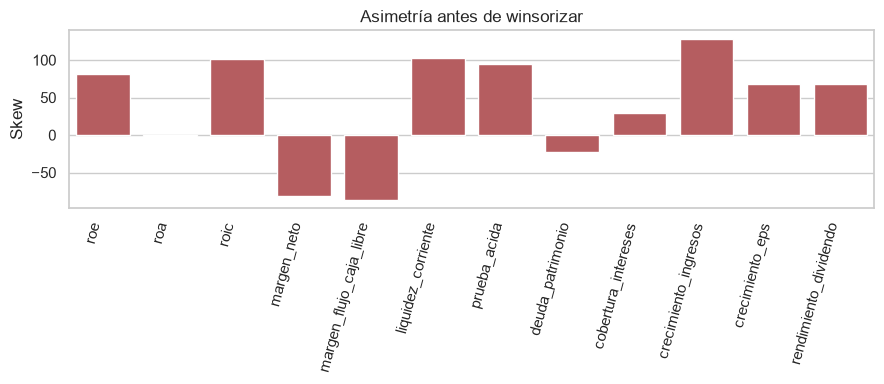

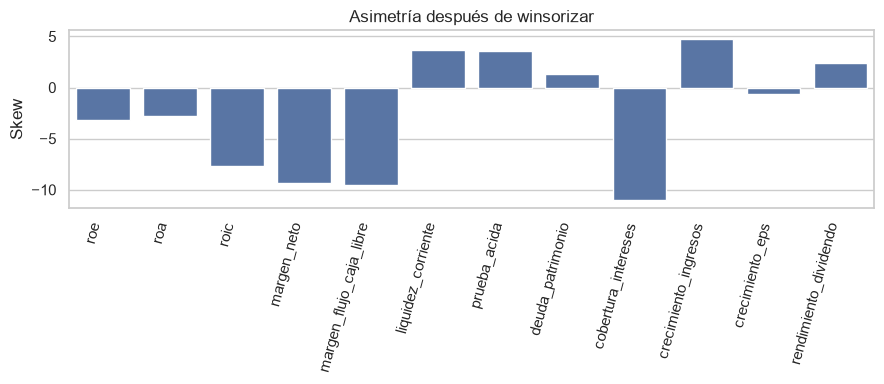

In [23]:
#Gráfico de barras: skew antes vs. después
#Barras: skew antes de winsorizar
plt.figure(figsize=(9, 4))
sns.barplot(x=comparacion_skew.index, y=comparacion_skew["skew_original"], color="#C44E52")
plt.xticks(rotation=75, ha="right")
plt.xlabel("")
plt.ylabel("Skew")
plt.title("Asimetría antes de winsorizar")
plt.tight_layout()
plt.show()

#Barras: skew después de winsorizar
plt.figure(figsize=(9, 4))
sns.barplot(x=comparacion_skew.index, y=comparacion_skew["skew_winsorizado"], color="#4C72B0")
plt.xticks(rotation=75, ha="right")
plt.xlabel("")
plt.ylabel("Skew")
plt.title("Asimetría después de winsorizar")
plt.tight_layout()
plt.show()

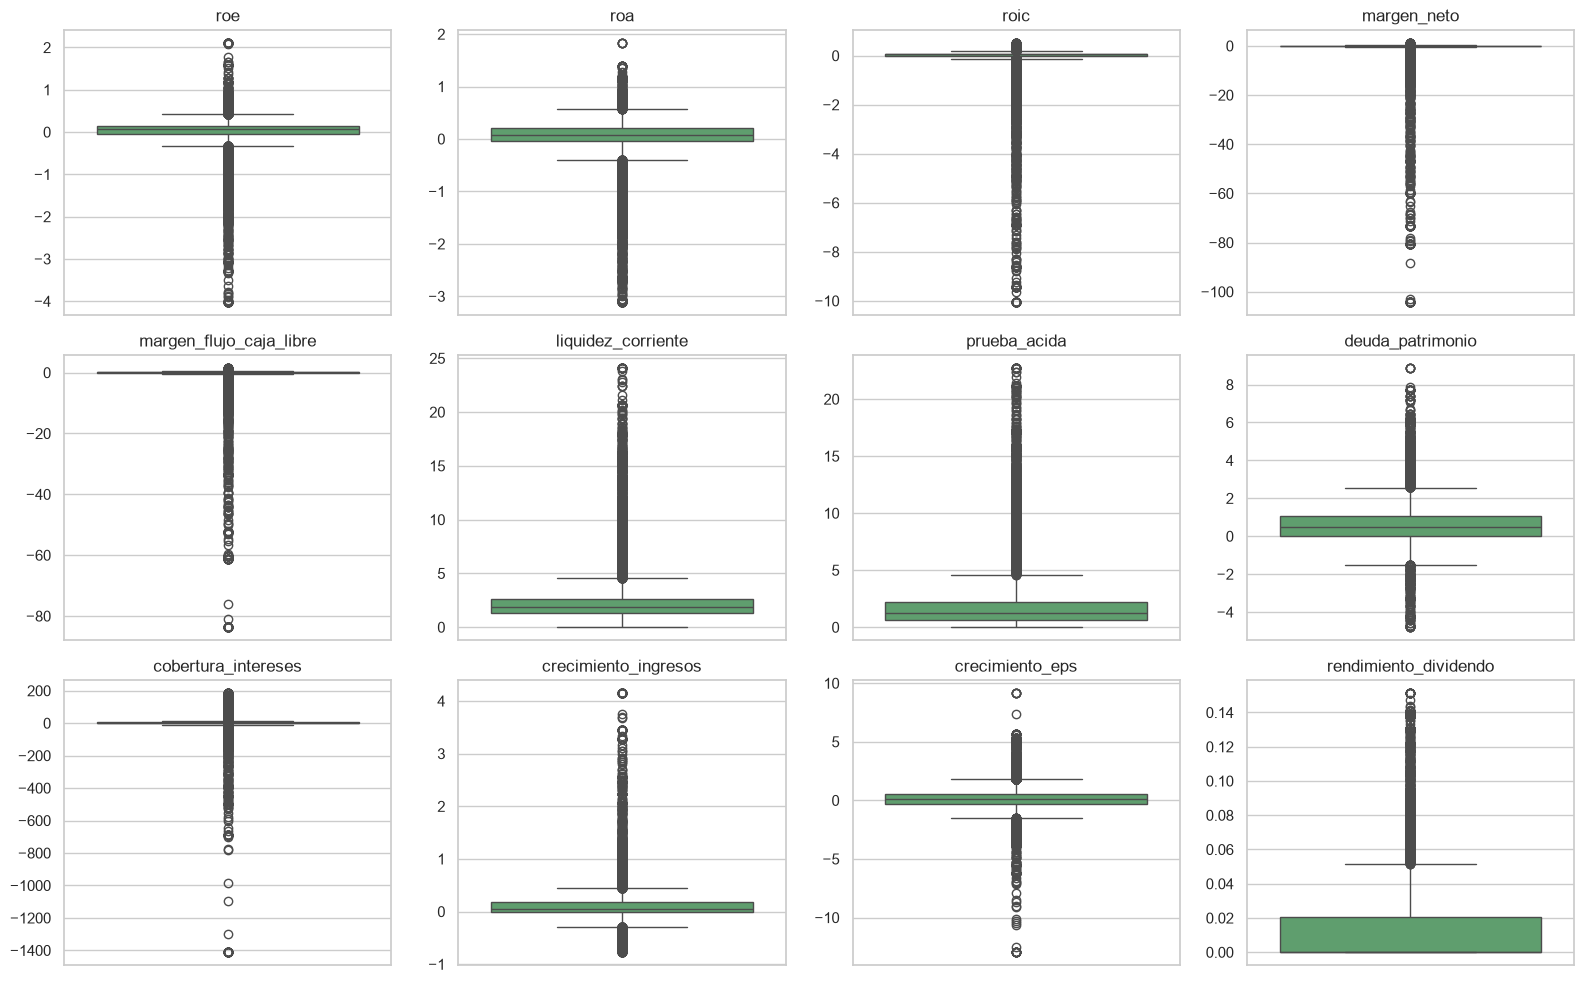

In [24]:
#Boxplot de los ratios ya winsorizados (escala original)
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for eje, columna in zip(axes.flatten(), columnas_score):
    sns.boxplot(y=df_reducido[columna], ax=eje, color="#55A868")
    eje.set_title(columna)
    eje.set_ylabel("")
plt.tight_layout()
plt.show()

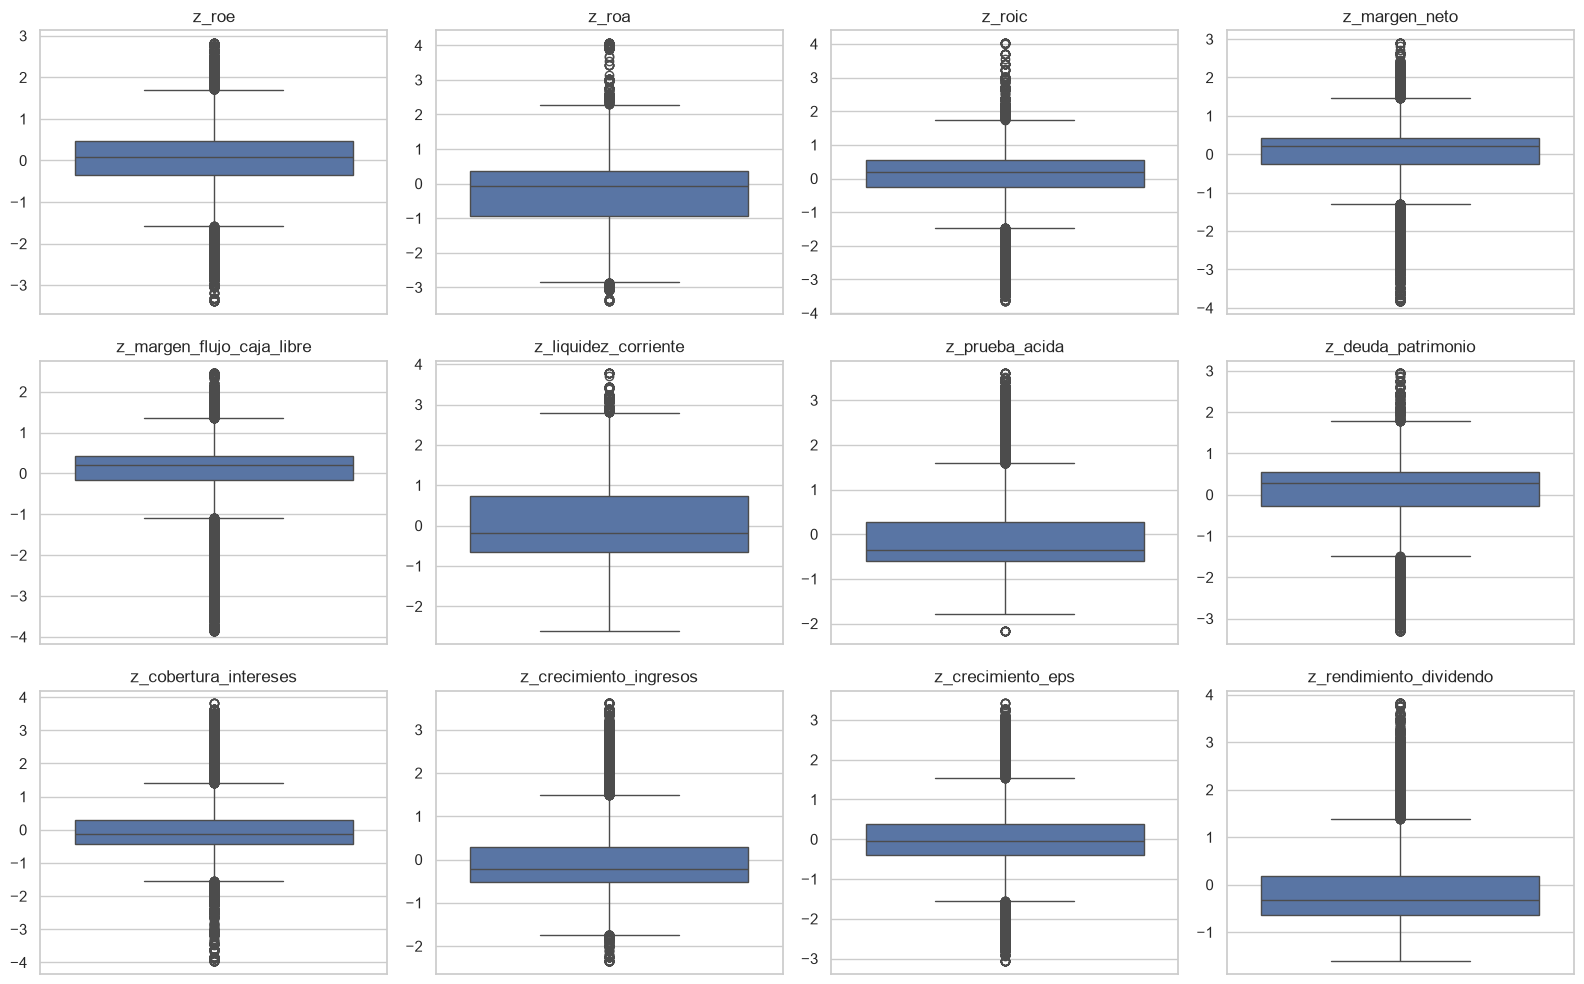

In [25]:
#Boxplot de los z-score (escala comparable entre sectores)
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for eje, columna in zip(axes.flatten(), columnas_z):
    sns.boxplot(y=df_reducido[columna], ax=eje, color="#4C72B0")
    eje.set_title(columna)
    eje.set_ylabel("")
plt.tight_layout()
plt.show()

#Por qué el score se arma por categoría y no como promedio directo de los 12 z-score

Si promediamos los 12 z-score directo, "rentabilidad" (5 ratios: roe, roa, roic,
margen_neto, margen_flujo_caja_libre) termina pesando 42% del score solo porque
elegimos más ratios de esa categoría, mientras "liquidez" y "apalancamiento" (2
ratios cada una) quedan en 17% cada una — un peso que nadie decidió a propósito.

Promediamos primero los z-score DENTRO de cada categoría, y después promediamos las
4 categorías entre sí. Así cada dimensión (rentabilidad, liquidez, apalancamiento,
crecimiento+dividendos) pesa 25% de forma explícita. La correlación entre este método
y el promedio directo da 0.93 — parecidos pero no iguales, así que la decisión sí
cambia el resultado.

In [26]:
categorias_score = {
    "rentabilidad": ["z_roe", "z_roa", "z_roic", "z_margen_neto", "z_margen_flujo_caja_libre"],
    "liquidez": ["z_liquidez_corriente", "z_prueba_acida"],
    "apalancamiento": ["z_deuda_patrimonio", "z_cobertura_intereses"],
    "crecimiento_dividendos": ["z_crecimiento_ingresos", "z_crecimiento_eps", "z_rendimiento_dividendo"],
}

for categoria, columnas in categorias_score.items():
    df_reducido[f"score_{categoria}"] = df_reducido[columnas].mean(axis=1)

columnas_categorias = [f"score_{categoria}" for categoria in categorias_score]
df_reducido["score_salud"] = df_reducido[columnas_categorias].mean(axis=1)

df_reducido["score_salud"].describe().round(3)

count    20878.000
mean         0.007
std          0.417
min         -1.875
25%         -0.240
50%         -0.008
75%          0.245
max          1.839
Name: score_salud, dtype: float64

#Por qué el semáforo usa un umbral fijo y no terciles
Los terciles fuerzan por definición que siempre haya exactamente 33% de empresas
"rojas", incluso en un año donde el sector esté sano en general — eso no refleja la
realidad, la inventa.

Probamos el score con un umbral fijo (±0.3) en cada año de 2014 a 2018, y la
proporción de verdes/rojos se mantiene bastante estable sola (14-18% verde, 13-16%
rojo) sin forzar nada — buena señal de que el score mide algo consistente y no solo
ruido de cada año.

Con ±0.3 el reparto general queda 21% verde / 58.5% amarillo / 20.5% rojo, razonable
para entrenar un clasificador más adelante. Probamos también ±0.5 y el amarillo se
come el 79% de los casos — ahí un modelo aprendería a predecir "amarillo" siempre,
así que descartamos ese umbral.

Nota importante: la correlación entre score_salud y variacion_precio_siguiente_anio
es prácticamente nula (-0.006), y con la clase binaria es débil (0.075). No es un
error de cálculo: que una empresa sea fundamentalmente sana no implica que su acción
suba el año siguiente (los mercados suelen tener ya "descontada" esa información). El
score sigue siendo válido como diagnóstico de salud financiera en sí mismo, pero si
el objetivo final es predecir la variación de precio, probablemente no alcance como
única variable.

In [27]:
umbral = 0.3

condiciones = [
    df_reducido["score_salud"] > umbral,
    df_reducido["score_salud"] < -umbral,
]
etiquetas = ["Verde", "Rojo"]
df_reducido["semaforo"] = np.select(condiciones, etiquetas, default="Amarillo")

print(df_reducido["semaforo"].value_counts(normalize=True).mul(100).round(1))
df_reducido[["ticker", "anio", "sector", "score_salud", "semaforo"]].head(10)

semaforo
Amarillo    58.5
Verde       21.0
Rojo        20.5
Name: proportion, dtype: float64


,ticker,anio,sector,score_salud,semaforo
0,PG,2014,Consumer Defensive,0.041104,Amarillo
1,VIPS,2014,Consumer Defensive,-0.030038,Amarillo
2,KR,2014,Consumer Defensive,-0.509803,Rojo
3,RAD,2014,Consumer Defensive,-0.099434,Amarillo
4,GIS,2014,Consumer Defensive,-0.112559,Amarillo
5,PM,2014,Consumer Defensive,0.236878,Amarillo
6,KO,2014,Consumer Defensive,0.002069,Amarillo
7,WMT,2014,Consumer Defensive,-0.252526,Amarillo
8,MDLZ,2014,Consumer Defensive,-0.366443,Rojo
9,MO,2014,Consumer Defensive,-0.088010,Amarillo
